# Plotting Notebook
Please use this is a guide to the type plots that you can create, as examples of the `hist`, `mplhep`, and other packages, as well as the use of the various functions that we have written in `plot_utils.py`. <br>
Use the the Table of Contents in Jupyter to view the different sections of the notebook to help navigating it.

In [26]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
%autoreload 1

In [28]:
import os, sys, glob, random
import pickle
import math
import multiprocessing
import itertools
import warnings
import json
import time
import numpy as np
from typing import Dict, List
from rich import print
from rich.pretty import pprint
from rich.console import Console
from rich.table import Table
from rich.progress import Progress, track
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from cycler import cycler
import hist
from hist import Hist
import mplhep as hep
from tabulate import tabulate
import scipy
from scipy.special import binom
import uproot
import ROOT
from iminuit import Minuit
from iminuit.cost import LeastSquares
from jacobi import propagate

%aimport plot_utils
%aimport plot_utils_extras
%aimport fill_utils
%aimport generic_utils

In [29]:
warnings.filterwarnings("ignore")
mpl.rcParams.update({"figure.max_open_warning": 0})
mpl.rcParams["figure.facecolor"] = "white"
hep.style.use("CMS")
np.set_printoptions(suppress=True)

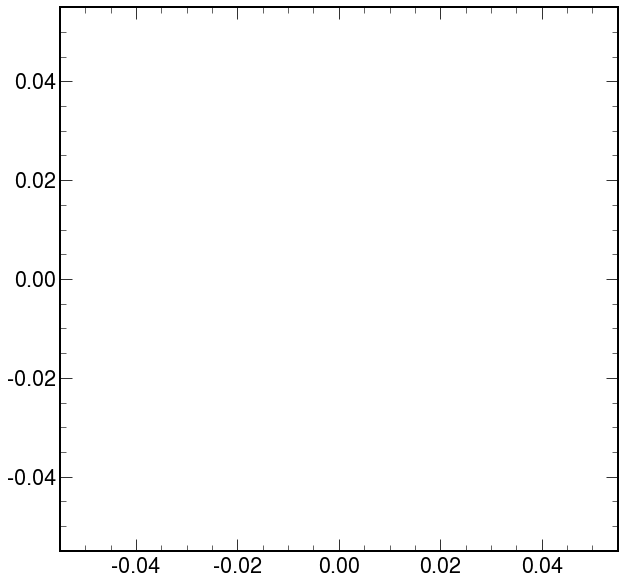

In [30]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"

In [31]:
print("The following output directories are available:")
!ls | grep output_histograms

The following output directories are available:

CR_cb_34mu_output_histograms
CR_cb_combine_output_histograms
CR_cb_output_histograms
CR_cb_postDYstudy_output_histograms
CR_light_postDYstudy_output_histograms
CR_prompt_34mu_leading_output_histograms
CR_prompt_34mu_output_histograms
CR_prompt_combine_output_histograms
CR_prompt_dimuon_output_histograms
CR_prompt_dystudy_output_histograms
CR_prompt_leading_output_histograms
CR_prompt_output_histograms
CR_prompt_postDYstudy_output_histograms
DYstudy_2_output_histograms
DYstudy_3_output_histograms
DYstudy_4_output_histograms
DYstudy_5_output_histograms
DYstudy_output_histograms
DYstudy_trigger_match_double_output_histograms
DYstudy_trigger_match_triple_output_histograms
DYstudy_trigger_one_path_output_histograms
fake_rate_output_histograms
gen_bug_comparisons_output_histograms
kinematics_output_histograms
nbjet_comparison_output_histograms
post_gensum_bug_output_histograms
SR_combine_new_trigger_output_histograms
SR_combine_old_trigger_output_histograms
SR_combine_output_histograms
SR_ex

## Load plots

In [32]:
plots = generic_utils.loader(tag="gen_bug_comparisons")

These are all the samples loaded.

In [33]:
keys = list(plots.keys())
pprint(keys)

[
│   'GluGluToSUEP_mS125.000_mPhi6.000_T6.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS125.000_mPhi6.000_T6.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS400.000_mPhi6.000_T6.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS400.000_mPhi6.000_T6.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS500.000_mPhi6.000_T6.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS500.000_mPhi6.000_T6.000_modeleptonic_13TeV_2018',
│   'ggHBSMpythia_hadronic_M400_MD3_T3_2018',
│   'ggHBSMpythia_hadronic_M400_MD6_T6_2018',
│   'ggHBSMpythia_leptonic_M125_MD3_T3_2018',
│   'ggHBSMpythia_leptonic_M125_MD6_T6_2018',
│   'ggHBSMpythia_leptonic_M400_MD3_T3_2018',
│   'ggHBSMpythia_leptonic_M400_MD6_T6_2018',
│   'ggHBSMpythia_leptonic_M500_MD3_T3_2018',
│   'ggHBSMpythia_leptonic_M500_MD6_T6_2018',
│   'ggHBSMpythia_leptonic_M700_MD3_T3_2018',
│   'ggHBSMpythia_leptonic_M700_MD6_T6_2018'
]

In [34]:
for key in plots[
    "GluGluToSUEP_mS125.000_mPhi6.000_T6.000_modehadronic_13TeV_2018"
].keys():
    pprint(f"{key}")

'SUEP_pt'

'SUEP_eta'

'SUEP_phi'

'Muon_pt'

'Muon_eta'

'Muon_phi'

'nMuon'

(125, 6, 6, 'leptonic')

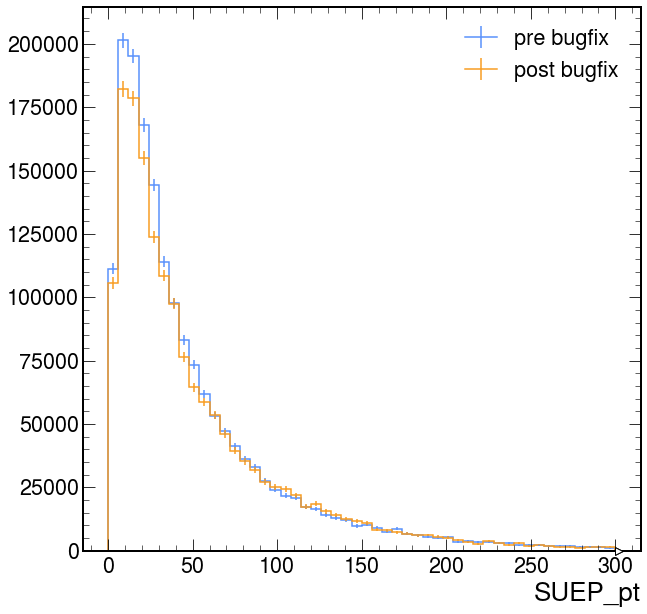

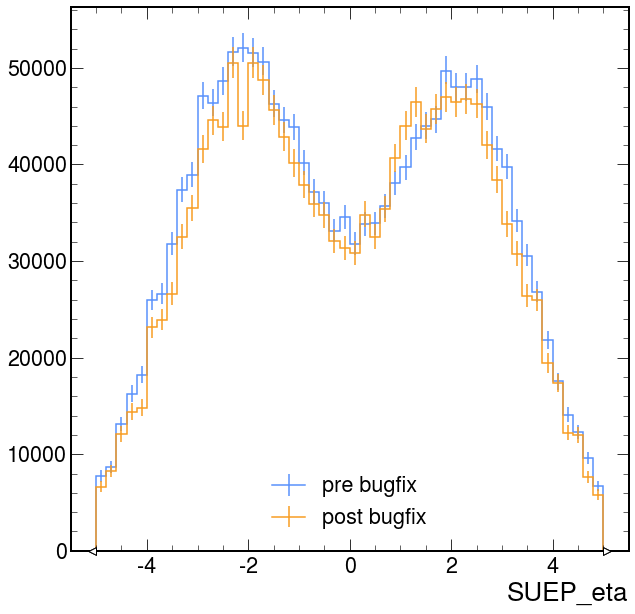

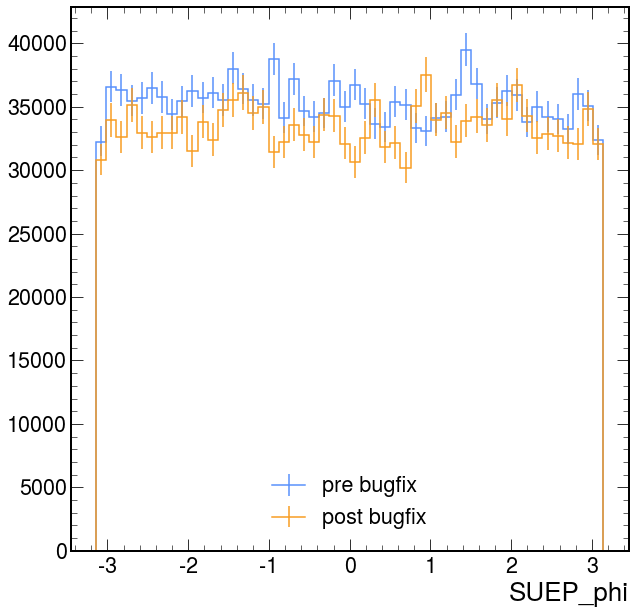

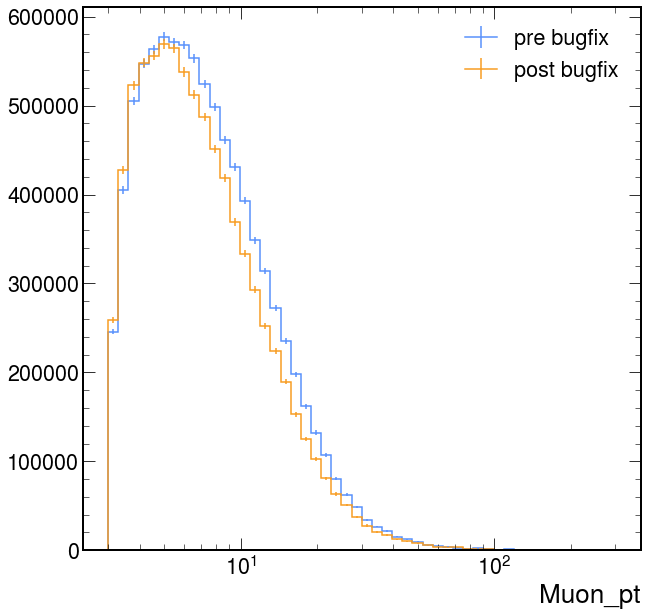

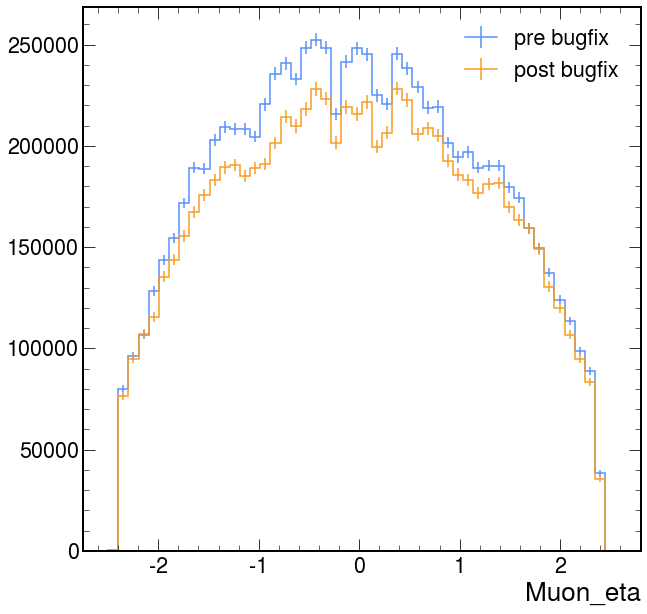

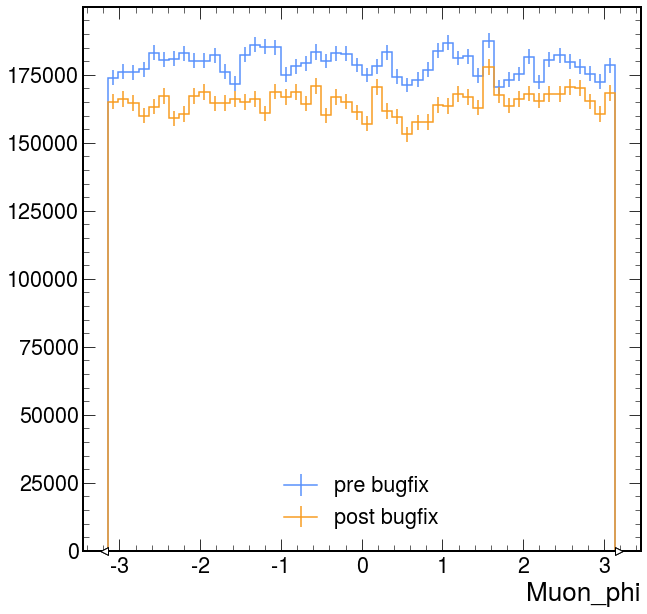

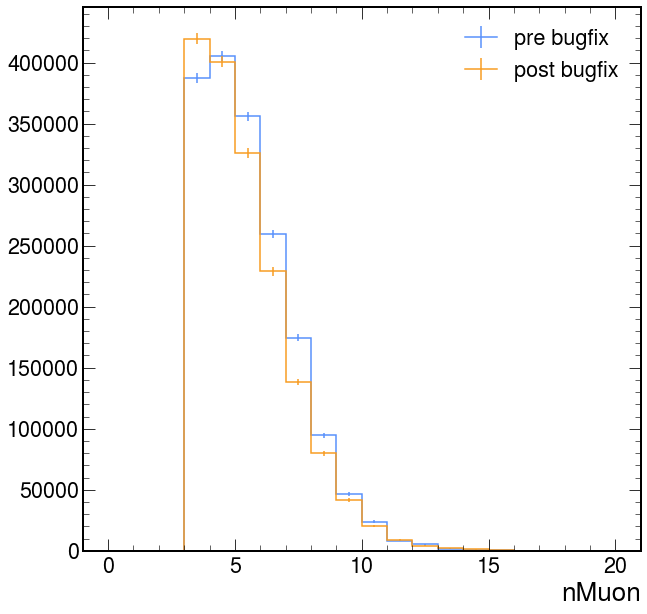

WeightedSum(value=356017, variance=1.46276e+07)

WeightedSum(value=296269, variance=1.46073e+07)

(400, 6, 6, 'leptonic')

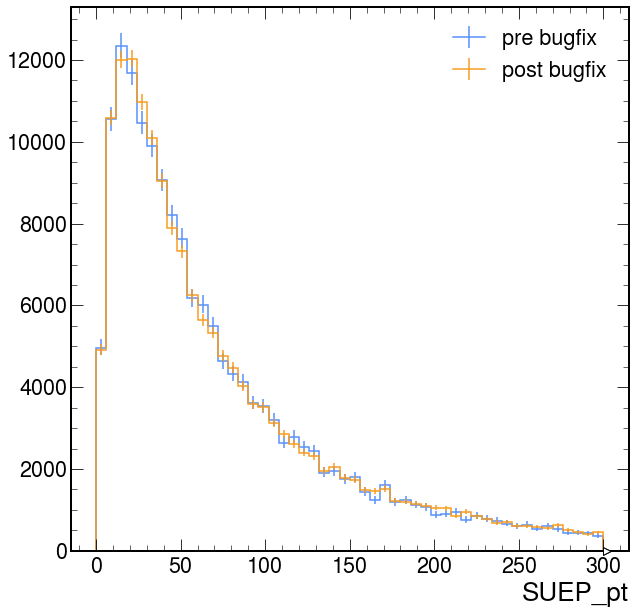

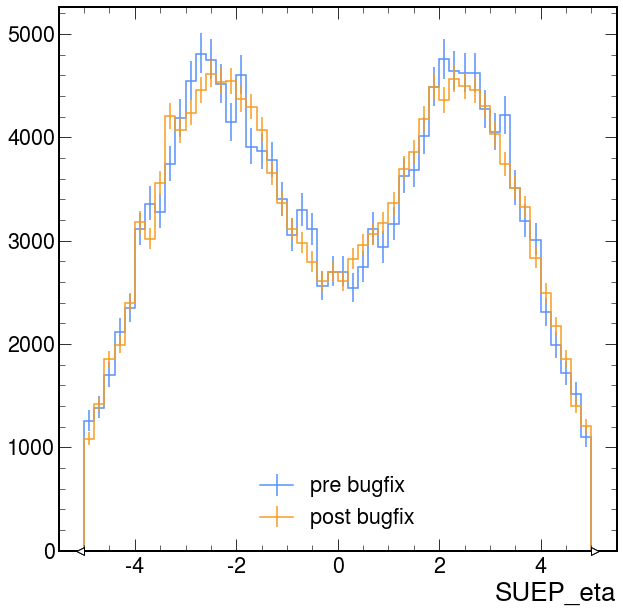

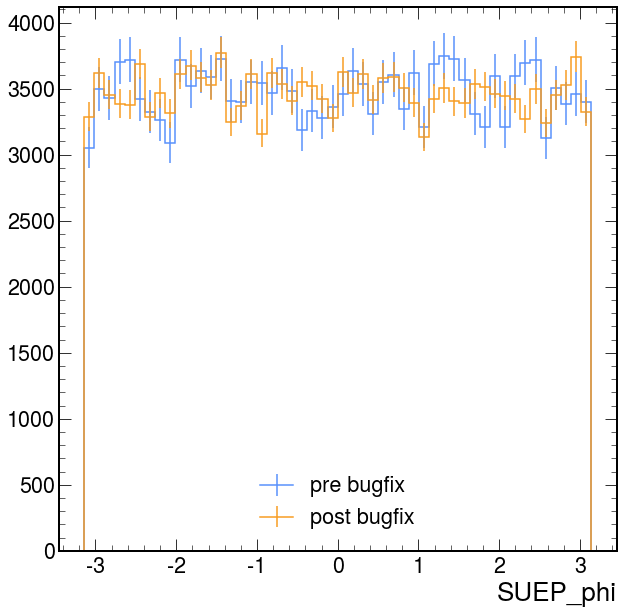

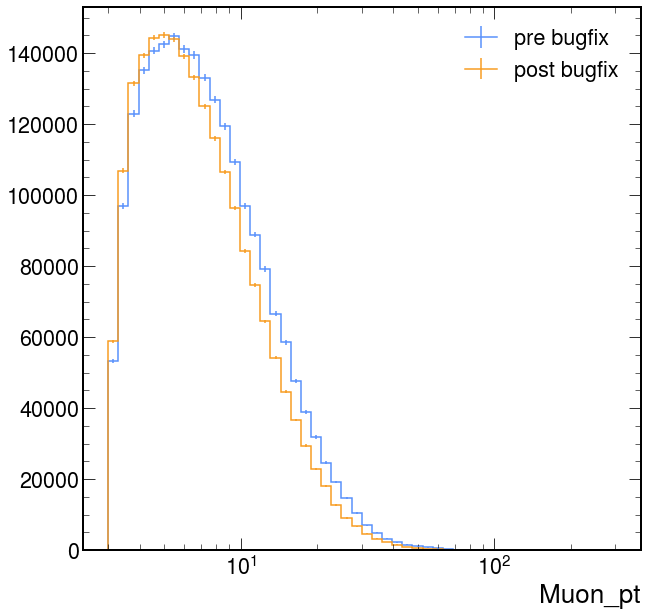

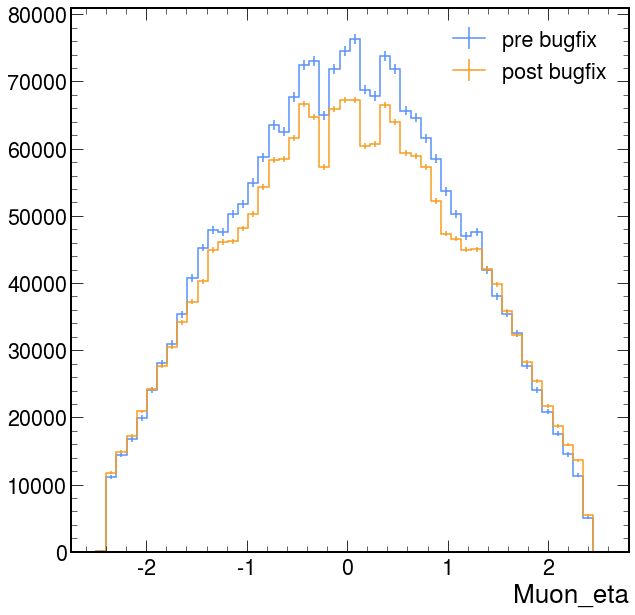

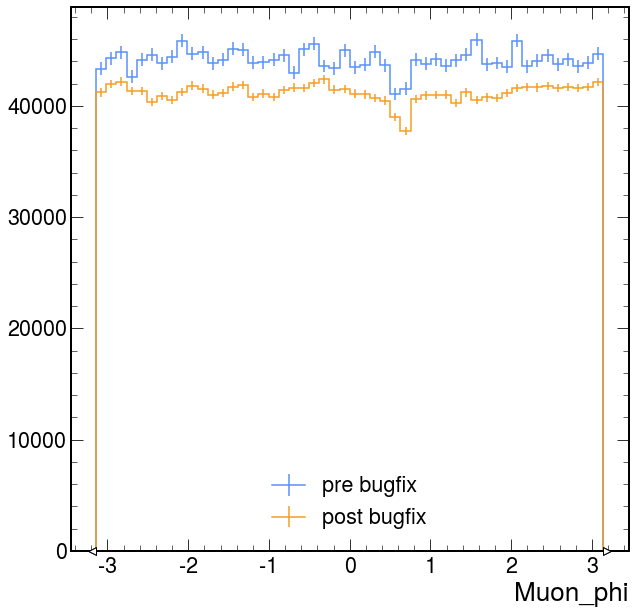

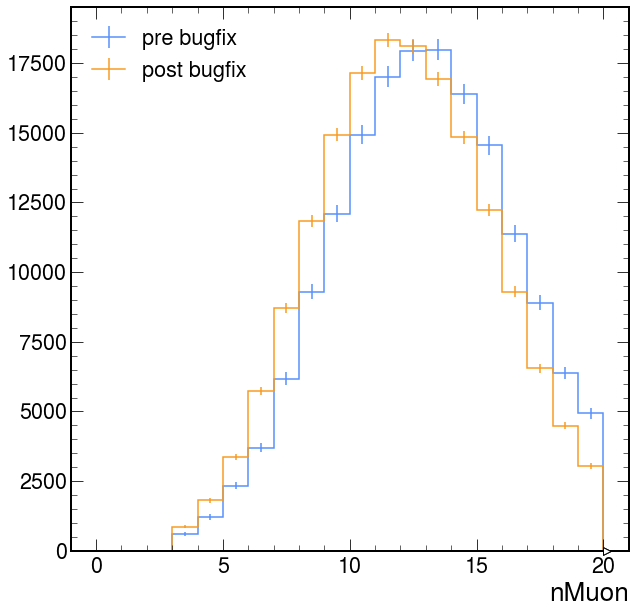

WeightedSum(value=165563, variance=1.2524e+06)

WeightedSum(value=161418, variance=561677)

(400, 6, 6, 'hadronic')

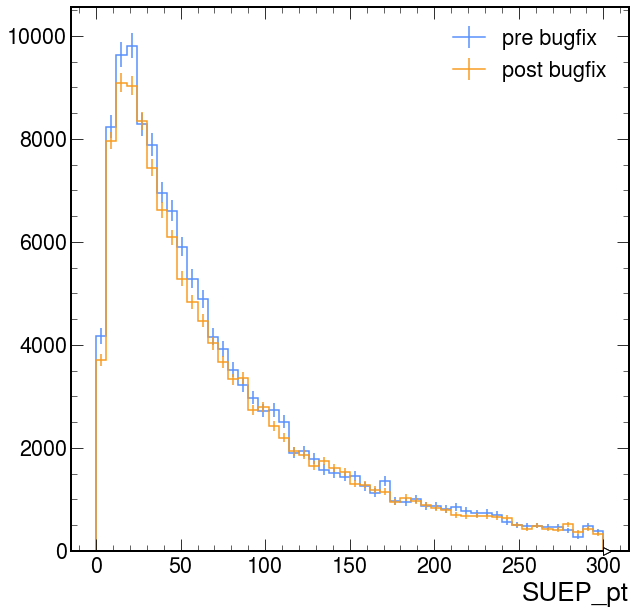

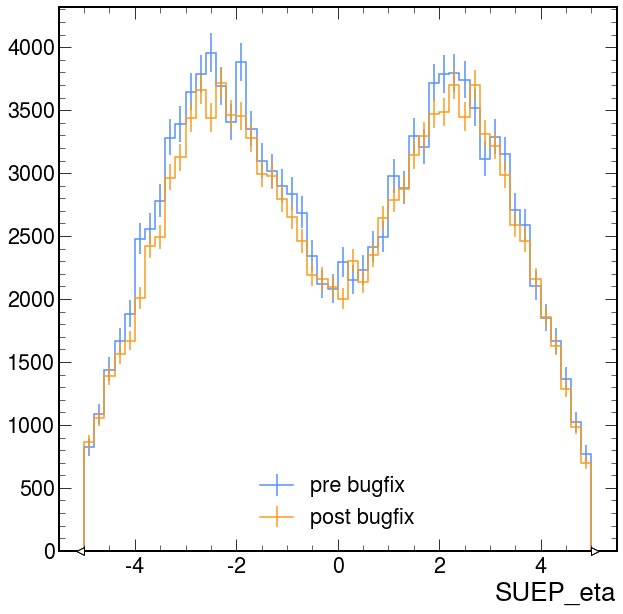

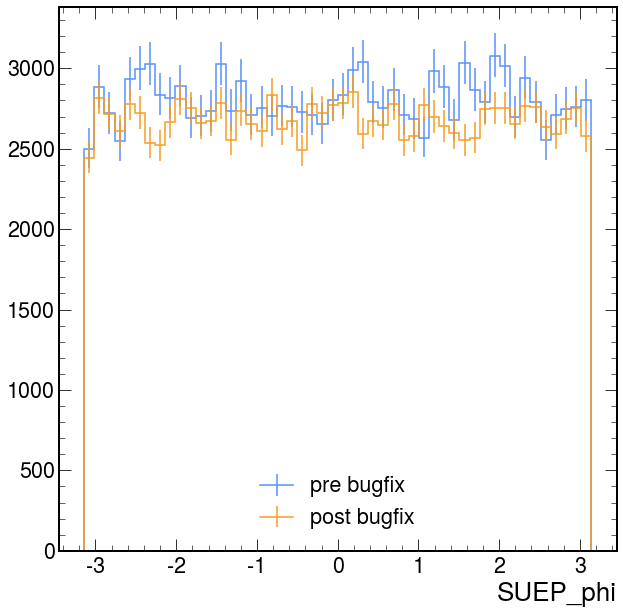

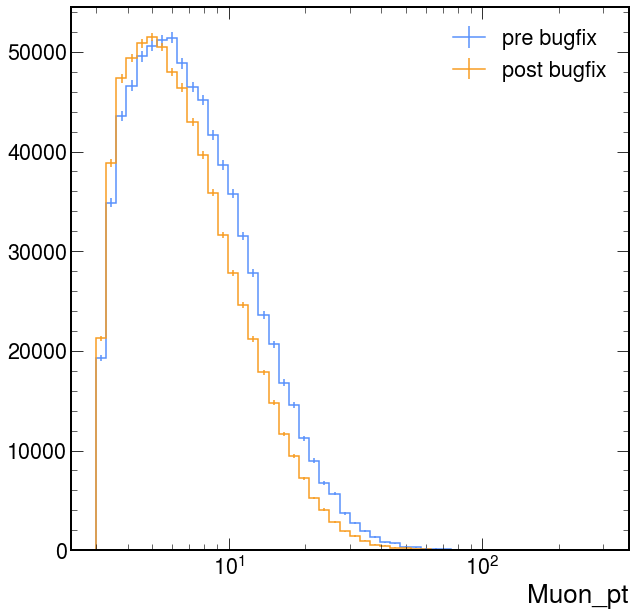

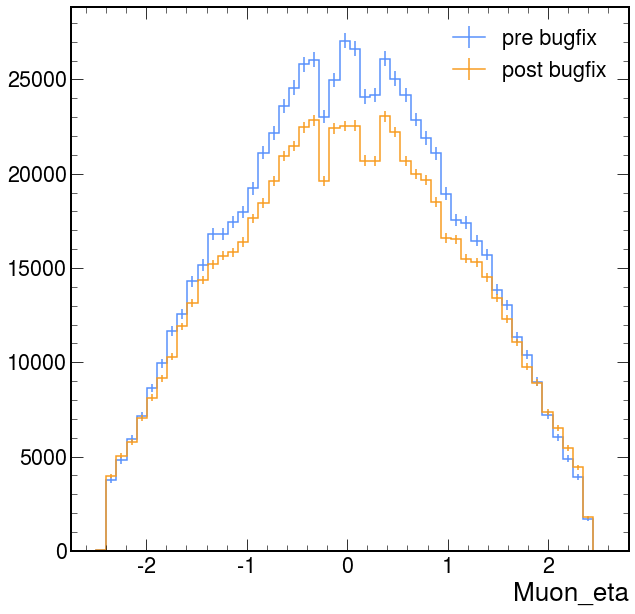

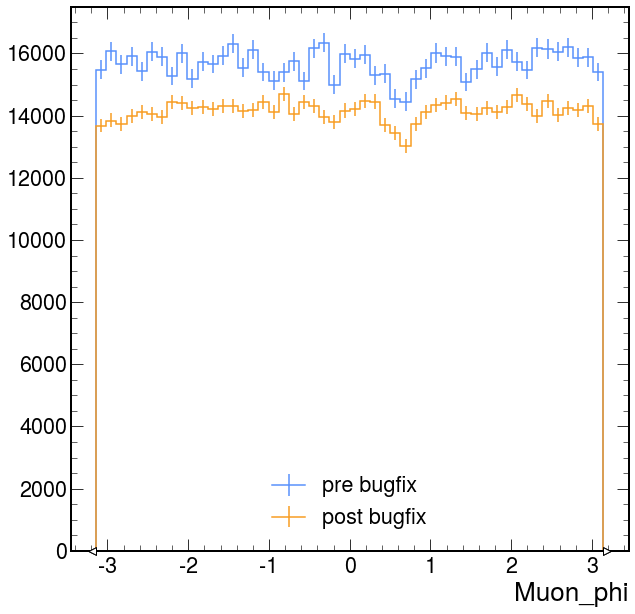

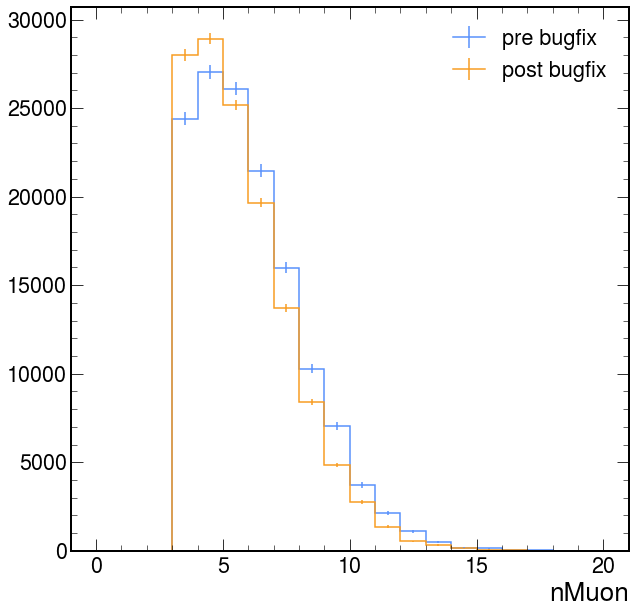

WeightedSum(value=41100.5, variance=238359)

WeightedSum(value=32176.1, variance=114247)

(500, 6, 6, 'leptonic')

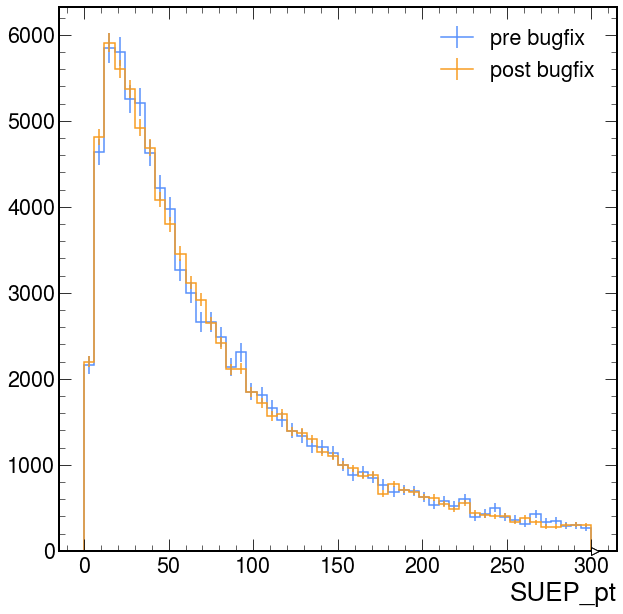

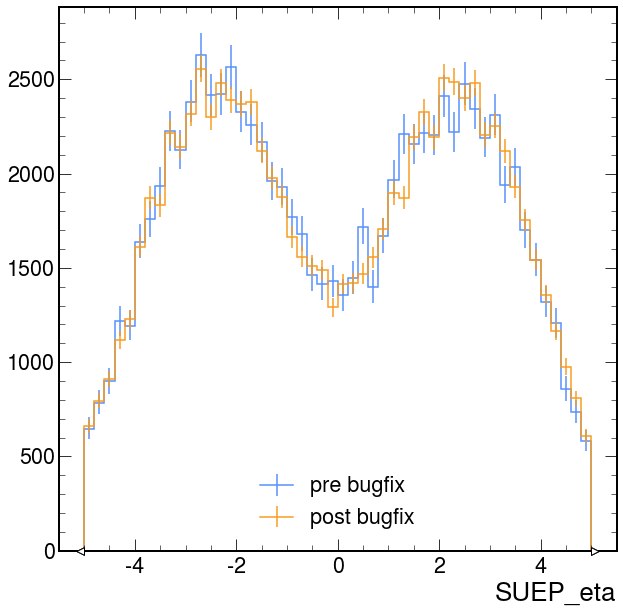

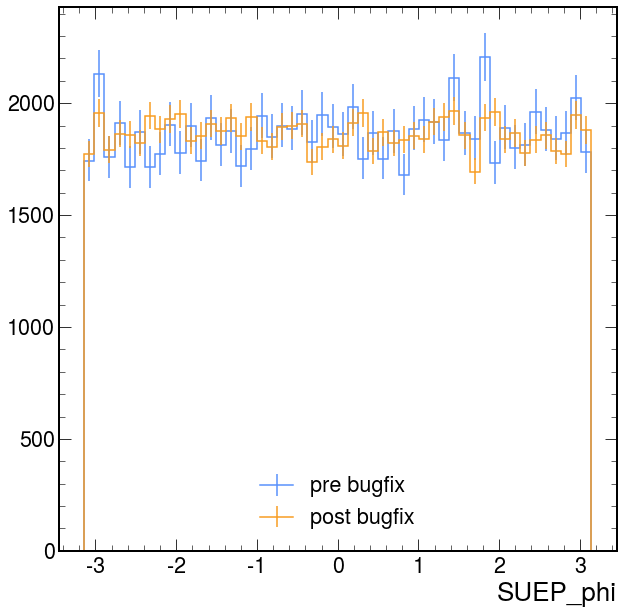

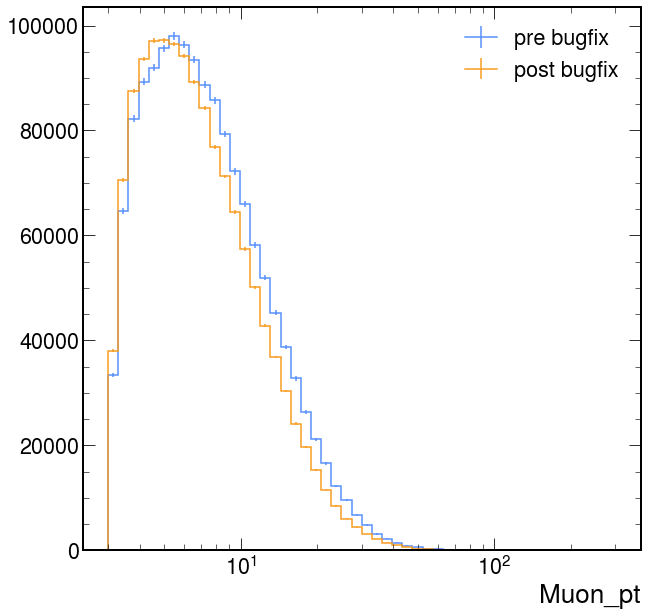

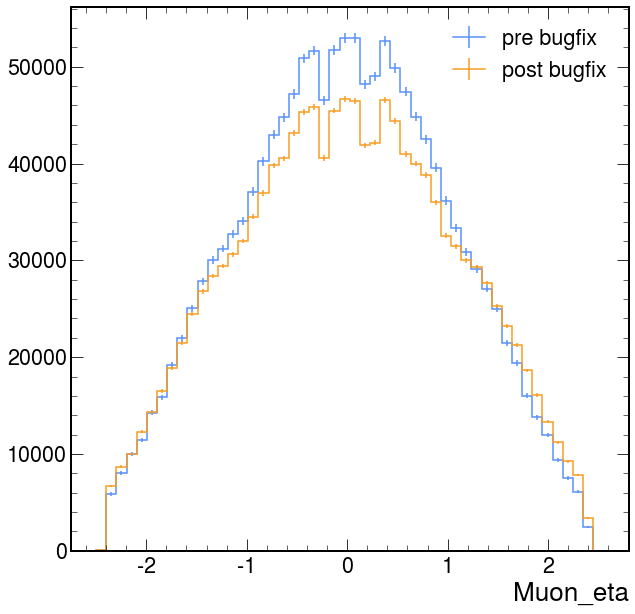

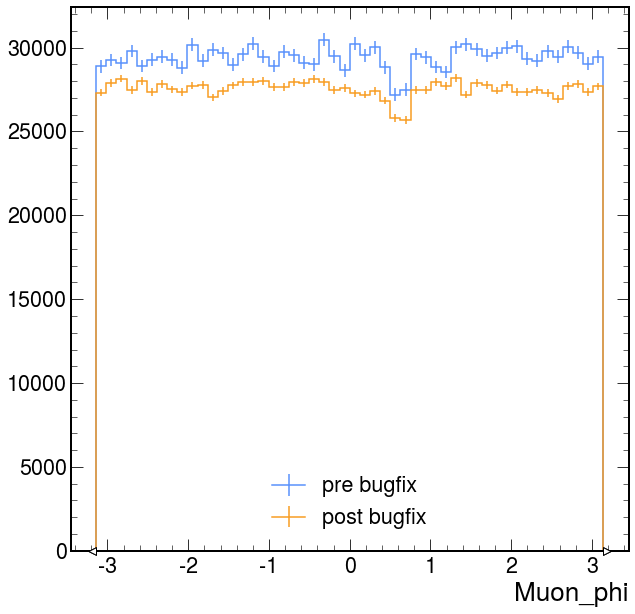

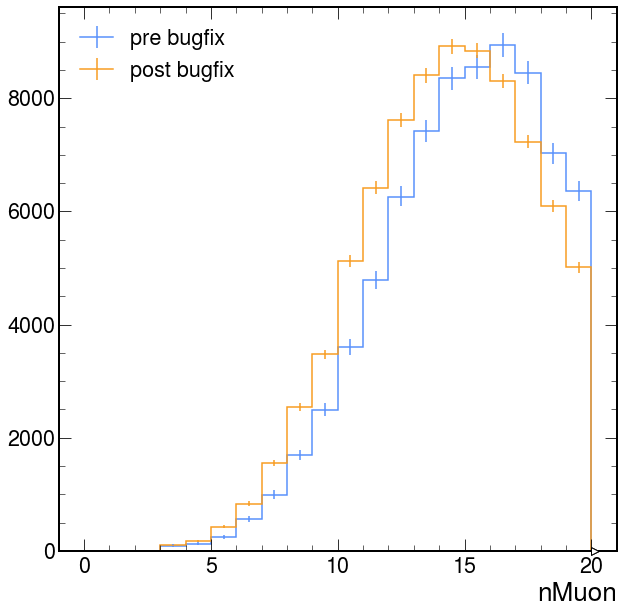

WeightedSum(value=92188.4, variance=452516)

WeightedSum(value=91636.6, variance=176213)

In [25]:
scan_points = [
    (125, 6, 6, 'leptonic'),
    (400, 6, 6, 'leptonic'),
    (400, 6, 6, 'hadronic'),
    (500, 6, 6, 'leptonic'),
]

hists = [
    'SUEP_pt',
    'SUEP_eta',
    'SUEP_phi',
    'Muon_pt',
    'Muon_eta',
    'Muon_phi',
    'nMuon',
]
for sp in scan_points:
    print(sp)
    for histogram in hists:
        plots[
            f'GluGluToSUEP_mS{sp[0]}.000_mPhi{sp[1]}.000_T{sp[2]}.000_mode{sp[3]}_13TeV_2018'
        ][histogram].plot(label="pre bugfix")
        plots[f'ggHBSMpythia_{sp[3]}_M{sp[0]}_MD{sp[1]}_T{sp[2]}_2018'][histogram].plot(label="post bugfix")
        if histogram == 'Muon_pt':
            plt.xscale('log')
        plt.legend()
        plt.title(f"mS={}, mPhi={},")
        plt.show()
        if histogram == 'nMuon':
            print(
                plots[
                    f'GluGluToSUEP_mS{sp[0]}.000_mPhi{sp[1]}.000_T{sp[2]}.000_mode{sp[3]}_13TeV_2018'
                ][histogram][7j::sum]
            )
            print(plots[f'ggHBSMpythia_{sp[3]}_M{sp[0]}_MD{sp[1]}_T{sp[2]}_2018'][histogram][7j::sum])

In [75]:
from cycler import cycler

cmap_petroff_6 = ["#5790fc", "#f89c20", "#e42536", "#964a8b", "#9c9ca1", "#7a21dd"]
cmap_petroff_10 = [
    "#3f90da",
    "#ffa90e",
    "#bd1f01",
    "#94a4a2",
    "#832db6",
    "#a96b59",
    "#e76300",
    "#b9ac70",
    "#717581",
    "#92dadd",
]

CMS = {"axes.prop_cycle": cycler("color", cmap_petroff_10)}
plt.style.use(CMS)

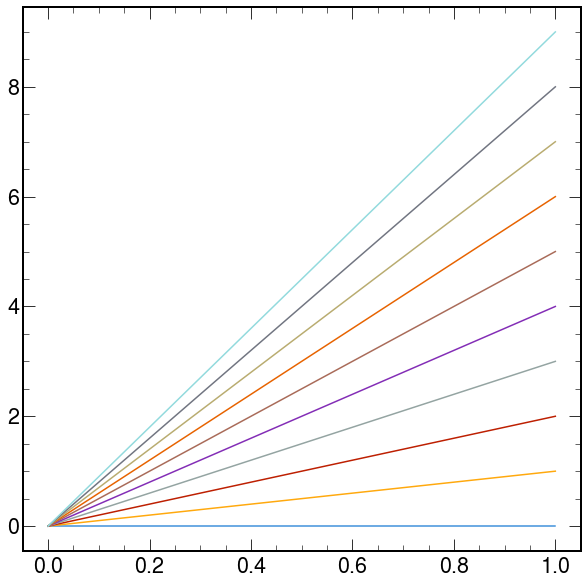

In [25]:
for i in range(10):
    plt.plot([0, 1], [0, i])
plt.show()